<h1 style="color: red; font-size: 48px; text-align: center;">🌐 Data Mesh in Practice</h1>
<h3 style="text-align:center; font-weight:400; color:#2d6cdf; margin-top:-6px;">Cross-Cloud Analytics <b>Without ETL</b></h3>
<center>
    <img src="https://media.giphy.com/media/26tn33aiTi1jkl6H6/giphy.gif" alt="data mesh animation" height="260" width="560">
</center>

<p align="center">
<img src="https://img.shields.io/badge/Architecture-Data%20Mesh-1e2a52?style=flat-square"/>
<img src="https://img.shields.io/badge/Federation-Trino%20style-2d6cdf?style=flat-square"/>
<img src="https://img.shields.io/badge/Governance-DataHub%20style-6c47d6?style=flat-square"/>
<img src="https://img.shields.io/badge/Data%20Movement-ZERO-2e9e6b?style=flat-square"/>
</p>

<h1 id="Introduction">👋 Introduction<a class="anchor-link" href="#Introduction">¶</a></h1><div class="alert alert-block alert-success" style="font-family: verdana; font-size: 18px; line-height: 1.7em; border-radius: 1.3em;">
    The objective of this project is to build a miniature, end-to-end <b>Data Mesh</b> &mdash; three domain-owned data products
    (Orders, Inventory, Marketing) living in three separate cloud stores, queried together through a single federated SQL engine
    <b>with no data movement</b>. Each team owns its data as a product (schema + quality contract + owner), and a thin federation
    layer lets anyone query <i>across</i> all products in a single SQL statement. This notebook builds the three domains, the
    cross-cloud federated query engine, automated PII governance, and a data-quality scorecard &mdash; runnable top to bottom.
</div>

<h1 id="Problem-Statement">📚 Problem Statement<a class="anchor-link" href="#Problem-Statement">¶</a></h1><div class="alert alert-block alert-info" style="font-family: verdana; font-size: 18px; line-height: 1.7em; border-radius: 1.3em;">
    Big companies keep their data in <b>silos</b> &mdash; Orders on <b>AWS</b>, Inventory on <b>Azure</b>, Marketing on <b>GCP</b>.
    Answering <i>one</i> cross-domain question ("which acquisition channel drives revenue for low-stock products?") normally means
    building slow, brittle <b>ETL pipelines</b> that copy data between clouds. That copying creates consistency bugs, compliance
    risk (GDPR data residency), and <b>3&ndash;6 week</b> lead times. A Data Mesh flips this: data stays where it lives and is
    queried in place &mdash; the consistency, compliance and speed problems disappear.
</div>

<h1 id="Data-Product-Description">🔭 Data Product Description<a class="anchor-link" href="#Data-Product-Description">¶</a></h1><div style="font-family:verdana; font-size: 18px; line-height: 1.7em;">
Three independent domains each publish a <b>data product</b>, stored in its own SQLite file to mimic three physically separate clouds:
<ol>
<li><b>Orders</b> &nbsp;🟠 <b>AWS</b> &nbsp;(Olist-style) &rarr; <code>orders.db</code>: <code>order_id</code>, <code>customer_id</code> (PII), <code>order_status</code>, <code>order_value</code>, <code>order_date</code>, <code>product_id</code>.</li>
<li><b>Inventory</b> &nbsp;🔵 <b>Azure</b> &nbsp;(Instacart-style) &rarr; <code>inventory.db</code>: <code>product_id</code>, <code>product_name</code>, <code>department</code>, <code>stock_qty</code>, <code>reorder_level</code>.</li>
<li><b>Marketing</b> &nbsp;🟢 <b>GCP</b> &nbsp;(GA4-style) &rarr; <code>marketing.db</code>: <code>event_id</code>, <code>customer_id</code> (PII), <code>channel</code>, <code>campaign</code>, <code>spend</code>, <code>event_date</code>.</li>
</ol>
The three products link on <code>product_id</code> (Orders &harr; Inventory) and <code>customer_id</code> (Orders &harr; Marketing) &mdash; the keys that make cross-cloud JOINs possible.
</div>

<h1 id="Project-Goals">🎯 Project Goals<a class="anchor-link" href="#Project-Goals">¶</a></h1><div class="alert alert-block alert-warning" style="font-family: verdana; font-size: 18px; line-height: 1.7em; border-radius: 1.3em;">
<ul>
<li>🧩 <b>Domain ownership</b> &mdash; ship each domain as a product with a schema + quality contract.</li>
<li>🔗 <b>Federation, not ETL</b> &mdash; one <code>ATTACH</code> + one <code>SELECT</code> joins AWS &times; Azure &times; GCP with zero data movement.</li>
<li>🛡️ <b>Federated governance</b> &mdash; auto-discover PII across every cloud from one control plane.</li>
<li>✅ <b>Contracts enforce trust</b> &mdash; turn SLA promises into a live data-quality scorecard.</li>
<li>⚡ <b>Self-service</b> &mdash; go from question to answer in seconds instead of a 6-week pipeline.</li>
</ul>
</div>

<h1 id="Table-of-Contents">🗂️ Table of Contents<a class="anchor-link" href="#Table-of-Contents">¶</a></h1>
<div style="font-family:verdana; font-size: 17px; line-height: 1.8em;">

1. [Setup](#1)
2. [The Three Domain Data Products](#2)
3. [Cross-Cloud Federation &mdash; Query Without ETL](#3)
4. [Federated Governance &mdash; Auto PII Discovery](#4)
5. [Data Quality &amp; SLA Scorecard](#5)
6. [Self-Service Time-to-Data Benchmark](#6)
7. [Key Takeaways](#7)

</div>

<a id="1"></a>
## 1 · Setup

Pure standard-library + the usual data stack (`pandas`, `matplotlib`). Each domain is loaded into its
**own** SQLite database file &mdash; that separation is what makes the three databases behave like three
separate clouds.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager  # noqa

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#f7f9fc",
    "axes.edgecolor": "#d0d7e2", "axes.grid": True, "grid.color": "#e7ecf3",
    "font.size": 11, "axes.titleweight": "bold", "axes.titlesize": 13,
})
PALETTE = {"AWS": "#ff9900", "Azure": "#0078d4", "GCP": "#34a853"}
print("Environment ready ✓")

Environment ready ✓


<a id="2"></a>
## 2 · The Three Domain Data Products

Each domain team publishes a **data product**. We create the three datasets, then write each one into a
*separate* SQLite file to mimic three physically separate clouds.

| Domain | Cloud | Source dataset | Store |
|---|---|---|---|
| **Orders** | 🟠 AWS | Brazilian E-Commerce (Olist) | `orders.db` |
| **Inventory** | 🔵 Azure | Instacart Market Basket | `inventory.db` |
| **Marketing** | 🟢 GCP | Google Analytics 4 (GA4) | `marketing.db` |

In [2]:
# --- Domain 1: Orders (Olist-style) -> AWS ---
orders = pd.DataFrame([
    ("O-1001","C-01","delivered",259.90,"2026-06-01","P-100"),
    ("O-1002","C-02","delivered", 89.00,"2026-06-01","P-101"),
    ("O-1003","C-03","shipped",  410.50,"2026-06-02","P-102"),
    ("O-1004","C-01","delivered", 35.25,"2026-06-02","P-103"),
    ("O-1005","C-04","canceled", 120.00,"2026-06-02","P-100"),
    ("O-1006","C-05","processing",540.00,"2026-06-03","P-104"),
    ("O-1007","C-02","delivered", 76.40,"2026-06-03","P-101"),
    ("O-1008","C-06","delivered",199.99,"2026-06-03","P-105"),
    ("O-1009","C-03","shipped",   60.00,"2026-06-03","P-102"),
    ("O-1010","C-07","delivered",310.10,"2026-06-04","P-104"),
], columns=["order_id","customer_id","order_status","order_value","order_date","product_id"])

# --- Domain 2: Inventory (Instacart-style) -> Azure ---
inventory = pd.DataFrame([
    ("P-100","Organic Bananas","produce",120,30),
    ("P-101","Whole Milk 1L","dairy",8,20),
    ("P-102","Sourdough Bread","bakery",45,15),
    ("P-103","Sparkling Water 6pk","beverages",200,50),
    ("P-104","Free Range Eggs","dairy",12,25),
    ("P-105","Dark Chocolate Bar","snacks",300,40),
], columns=["product_id","product_name","department","stock_qty","reorder_level"])

# --- Domain 3: Marketing (GA4-style) -> GCP ---
marketing = pd.DataFrame([
    ("E-9001","C-01","email","winter_sale",4.50,"2026-05-31"),
    ("E-9002","C-02","paid_search","brand_terms",12.00,"2026-05-31"),
    ("E-9003","C-03","social","influencer_q2",7.25,"2026-06-01"),
    ("E-9004","C-04","organic","none",0.00,"2026-06-01"),
    ("E-9005","C-05","paid_search","competitor_terms",18.40,"2026-06-02"),
    ("E-9006","C-06","email","winter_sale",3.10,"2026-06-02"),
    ("E-9007","C-07","social","influencer_q2",9.80,"2026-06-03"),
    ("E-9008","C-01","paid_search","brand_terms",11.00,"2026-06-03"),
], columns=["event_id","customer_id","channel","campaign","spend","event_date"])

print(f"Orders:    {len(orders)} rows   (AWS)")
print(f"Inventory: {len(inventory)} rows   (Azure)")
print(f"Marketing: {len(marketing)} rows   (GCP)")
orders.head()

Orders:    10 rows   (AWS)
Inventory: 6 rows   (Azure)
Marketing: 8 rows   (GCP)


,order_id,customer_id,order_status,order_value,order_date,product_id
0,O-1001,C-01,delivered,259.90,2026-06-01,P-100
1,O-1002,C-02,delivered,89.00,2026-06-01,P-101
2,O-1003,C-03,shipped,410.50,2026-06-02,P-102
3,O-1004,C-01,delivered,35.25,2026-06-02,P-103
4,O-1005,C-04,canceled,120.00,2026-06-02,P-100


In [3]:
# Load each domain into its OWN database file = its own 'cloud' (zero shared storage).
orders.to_sql("orders", sqlite3.connect("orders.db"), if_exists="replace", index=False)
inventory.to_sql("inventory", sqlite3.connect("inventory.db"), if_exists="replace", index=False)
marketing.to_sql("marketing", sqlite3.connect("marketing.db"), if_exists="replace", index=False)
print("Three separate 'clouds' provisioned: orders.db (AWS), inventory.db (Azure), marketing.db (GCP) ✓")

Three separate 'clouds' provisioned: orders.db (AWS), inventory.db (Azure), marketing.db (GCP) ✓


<a id="3"></a>
## 3 · Cross-Cloud Federation — Query Without ETL

This is the heart of the mesh. We open one connection and **`ATTACH`** all three database files.
Now a *single* SQL query can `JOIN` across AWS, Azure and GCP — and the data never leaves its own
store. This is exactly what **Trino** does across real clouds.

```text
  orders.db (AWS) ─┐
  inventory.db(Azure)├──►  ATTACH  ──►  one SELECT joins all three  (no copy)
  marketing.db(GCP)─┘
```

In [4]:
def federate():
    """One connection with all three clouds attached -> federated SQL."""
    conn = sqlite3.connect(":memory:")
    conn.execute("ATTACH DATABASE 'orders.db'    AS orders")
    conn.execute("ATTACH DATABASE 'inventory.db' AS inventory")
    conn.execute("ATTACH DATABASE 'marketing.db' AS marketing")
    return conn

fed = federate()
print("Federation layer online — 3 clouds attached, 0 bytes moved ✓")

Federation layer online — 3 clouds attached, 0 bytes moved ✓


**Federated Query A — Customer 360 across all three clouds** (AWS × Azure × GCP)

In [5]:
customer_360 = pd.read_sql("""
    SELECT o.customer_id,
           COUNT(DISTINCT o.order_id)            AS orders,
           ROUND(SUM(o.order_value), 2)          AS lifetime_value,
           GROUP_CONCAT(DISTINCT i.department)   AS departments,
           GROUP_CONCAT(DISTINCT m.channel)      AS channels
    FROM orders.orders o
    JOIN inventory.inventory i ON i.product_id = o.product_id
    LEFT JOIN marketing.marketing m ON m.customer_id = o.customer_id
    GROUP BY o.customer_id
    ORDER BY lifetime_value DESC
""", fed)
customer_360

,customer_id,orders,lifetime_value,departments,channels
0,C-01,2,590.30,"produce,beverages","email,paid_search"
1,C-05,1,540.00,dairy,paid_search
2,C-03,2,470.50,bakery,social
3,C-07,1,310.10,dairy,social
4,C-06,1,199.99,snacks,email
5,C-02,2,165.40,dairy,paid_search
6,C-04,1,120.00,produce,organic


**Federated Query B — Revenue by acquisition channel** (Orders on AWS × Marketing on GCP)

In [6]:
rev_by_channel = pd.read_sql("""
    SELECT m.channel,
           ROUND(SUM(m.spend), 2)        AS marketing_spend,
           ROUND(SUM(o.order_value), 2)  AS order_revenue
    FROM marketing.marketing m
    JOIN orders.orders o ON o.customer_id = m.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY m.channel
    ORDER BY order_revenue DESC
""", fed)
rev_by_channel

,channel,marketing_spend,order_revenue
0,email,12.1,495.14
1,paid_search,46.0,460.55
2,social,9.8,310.10


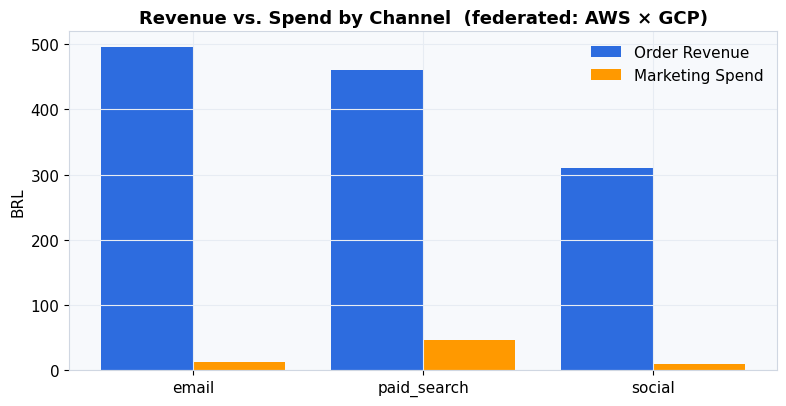

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.2))
x = range(len(rev_by_channel))
ax.bar([i-0.2 for i in x], rev_by_channel["order_revenue"], width=0.4, label="Order Revenue", color="#2d6cdf")
ax.bar([i+0.2 for i in x], rev_by_channel["marketing_spend"], width=0.4, label="Marketing Spend", color="#ff9900")
ax.set_xticks(list(x)); ax.set_xticklabels(rev_by_channel["channel"])
ax.set_title("Revenue vs. Spend by Channel  (federated: AWS × GCP)")
ax.set_ylabel("BRL"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

**Federated Query C — Delivered orders for products below reorder level** (AWS × Azure)
A classic supply-chain question that *requires* joining two different clouds.

In [8]:
low_stock = pd.read_sql("""
    SELECT o.order_id, i.product_name, i.stock_qty, i.reorder_level
    FROM orders.orders o
    JOIN inventory.inventory i ON i.product_id = o.product_id
    WHERE o.order_status = 'delivered' AND i.stock_qty < i.reorder_level
    ORDER BY i.stock_qty ASC
""", fed)
low_stock

,order_id,product_name,stock_qty,reorder_level
0,O-1002,Whole Milk 1L,8,20
1,O-1007,Whole Milk 1L,8,20
2,O-1010,Free Range Eggs,12,25


<a id="4"></a>
## 4 · Federated Governance — Auto PII Discovery

A Data Mesh needs **one** governance view across every cloud. Each data product ships a schema contract
that flags **PII** columns. The catalog scans all contracts and produces a single GDPR map — the local
stand-in for **DataHub**.

In [9]:
# Schema contracts (column -> is it PII?) for each data product
contracts = {
    "orders":    {"order_id": False, "customer_id": True,  "order_status": False,
                  "order_value": False, "order_date": False, "product_id": False},
    "inventory": {"product_id": False, "product_name": False, "department": False,
                  "stock_qty": False, "reorder_level": False},
    "marketing": {"event_id": False, "customer_id": True, "channel": False,
                  "campaign": False, "spend": False, "event_date": False},
}
cloud_of = {"orders": "AWS", "inventory": "Azure", "marketing": "GCP"}

pii = [{"data_product": dp, "cloud": cloud_of[dp], "column": col, "classification": "PII"}
       for dp, cols in contracts.items() for col, is_pii in cols.items() if is_pii]
pd.DataFrame(pii)

,data_product,cloud,column,classification
0,orders,AWS,customer_id,PII
1,marketing,GCP,customer_id,PII


<a id="5"></a>
## 5 · Data Quality & SLA Scorecard

Each product is validated against its **quality contract** (completeness, not-null, uniqueness,
allowed values) — the role **Great Expectations + dbt** play in production. Any failed check is a
**contract breach**.

In [10]:
def score(df, not_null, unique, allowed=None):
    checks = []
    checks.append(("min_rows", len(df) >= 5))
    for c in not_null:
        checks.append((f"not_null[{c}]", df[c].notna().all()))
    for c in unique:
        checks.append((f"unique[{c}]", df[c].is_unique))
    for c, vals in (allowed or {}).items():
        checks.append((f"allowed[{c}]", df[c].isin(vals).all()))
    passed = sum(ok for _, ok in checks)
    return passed, len(checks), round(100*passed/len(checks), 1)

results = pd.DataFrame([
    ("orders",   *score(orders,   ["order_id","customer_id","order_status"], ["order_id"],
                        {"order_status": ["delivered","shipped","canceled","processing"]})),
    ("inventory",*score(inventory,["product_id","product_name","stock_qty"], ["product_id"])),
    ("marketing",*score(marketing,["event_id","customer_id","channel"], ["event_id"],
                        {"channel": ["email","paid_search","social","organic"]})),
], columns=["data_product","checks_passed","checks_total","quality_score"])
results["status"] = results["quality_score"].map(lambda s: "✅ OK" if s == 100 else "⚠️ BREACH")
results

,data_product,checks_passed,checks_total,quality_score,status
0,orders,6,6,100.0,✅ OK
1,inventory,5,5,100.0,✅ OK
2,marketing,6,6,100.0,✅ OK


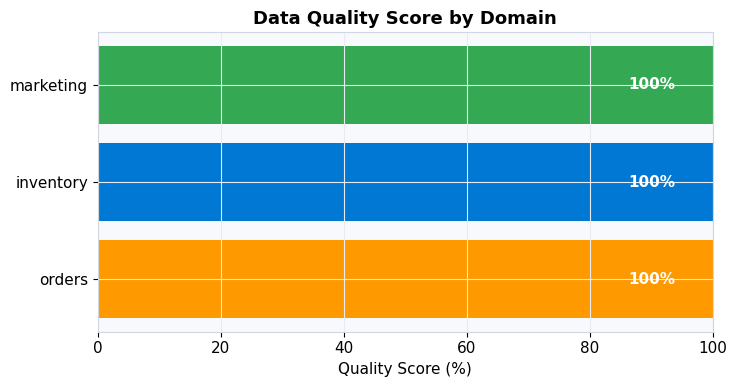

Mesh health: HEALTHY   |   Average quality score: 100.0%


In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4))
colors = [PALETTE[c] for c in ["AWS","Azure","GCP"]]
bars = ax.barh(results["data_product"], results["quality_score"], color=colors)
for b, s in zip(bars, results["quality_score"]):
    ax.text(s-6, b.get_y()+b.get_height()/2, f"{s:.0f}%", va="center", ha="right",
            color="white", fontweight="bold")
ax.set_xlim(0, 100); ax.set_title("Data Quality Score by Domain")
ax.set_xlabel("Quality Score (%)")
plt.tight_layout(); plt.show()

health = "HEALTHY" if (results.quality_score == 100).all() else "DEGRADED"
print(f"Mesh health: {health}   |   Average quality score: {results.quality_score.mean():.1f}%")

<a id="6"></a>
## 6 · Self-Service Time-to-Data Benchmark

The business case of a Data Mesh: an analyst goes from question to answer in **seconds**, not weeks,
because there is no ETL ticket and no data copy. We contrast the traditional pipeline lifecycle with the
mesh's self-service path.

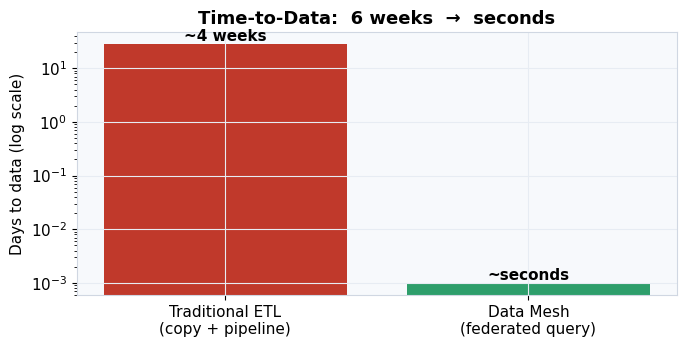

In [12]:
bench = pd.DataFrame({
    "approach": ["Traditional ETL\n(copy + pipeline)", "Data Mesh\n(federated query)"],
    "days_to_data": [28, 0.001],   # ~4 weeks vs a few seconds
})
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(bench["approach"], bench["days_to_data"], color=["#c0392b", "#2e9e6b"])
ax.set_yscale("log"); ax.set_ylabel("Days to data (log scale)")
ax.set_title("Time-to-Data:  6 weeks  →  seconds")
for i, v in enumerate(bench["days_to_data"]):
    label = "~4 weeks" if v > 1 else "~seconds"
    ax.text(i, v, label, ha="center", va="bottom", fontweight="bold")
plt.tight_layout(); plt.show()

<a id="7"></a>
## 7 · Key Takeaways

<div style="background:#f0f5ff;border-left:5px solid #2d6cdf;padding:16px 20px;border-radius:8px">

- 🧩 **Domain ownership** — each team ships its data as a product with a schema + quality contract.
- 🔗 **Federation, not ETL** — one `ATTACH` + one `SELECT` joins AWS × Azure × GCP with **zero data movement**.
- 🛡️ **Federated governance** — PII is auto-discovered across every cloud from one control plane.
- ✅ **Contracts enforce trust** — automated quality checks turn SLA promises into a live scorecard.
- ⚡ **Self-service** — analysts go from question to answer in seconds instead of a 6-week pipeline.

</div>

> This notebook is the analytics companion to a runnable **FastAPI backend** that exposes the same mesh
> (catalog, federation, portal, quality, monitoring) as a REST API. Same architecture, two front doors.

<h1 style="color: red; font-size: 40px; text-align: center;">🙏 Thank You!</h1>
<center>
    <img src="https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExMXo3ZjUzbG1taXE1eGdkcWNubHkxdTlsNjEzZ2JwY2p2b2hqbTV5aSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9cw/Gz6nYcm8oXE4dFTC8j/giphy.gif" height="120" width="240">
</center>
<p align="center" style="font-family:verdana; font-size:18px; color:#2d6cdf;">
⭐ If this helped you understand <b>Data Mesh</b>, an upvote is appreciated! ⭐
</p>